# Triagegeist — Phase 3: Fusion, Tuning & Bias Analysis

> **Scores going in:**
> - Structured only F1: 0.8949 | QWK: 0.9499
> - Full features + NLP F1: 0.9989 | QWK: 0.9995
>
> Phase 3 goal: squeeze final performance, bias analysis (25 pts), SHAP plots, final submission CSV.

## Session Start — Load Everything from Kaggle Working Directory

In [1]:
import numpy as np
import pandas as pd
import os

WORKING_DIR = '/kaggle/working/'
triagegeist_path = '/kaggle/input/competitions/triagegeist'

# Load feature matrices saved in Phase 2
X_train_full = pd.read_parquet(WORKING_DIR + 'X_train_full.parquet')
X_test_full  = pd.read_parquet(WORKING_DIR + 'X_test_full.parquet')
oof_phase2   = np.load(WORKING_DIR + 'oof_phase2.npy')
test_phase2  = np.load(WORKING_DIR + 'test_phase2.npy')

# Reload raw data for bias analysis subgroup columns
train_raw    = pd.read_csv(os.path.join(triagegeist_path, 'train.csv'))
patient_hist = pd.read_csv(os.path.join(triagegeist_path, 'patient_history.csv'))
train_meta   = train_raw.merge(patient_hist, on='patient_id', how='left')

TARGET = 'triage_acuity'
y = train_meta[TARGET].values - 1  # 0-indexed

print('X_train_full:', X_train_full.shape)
print('X_test_full: ', X_test_full.shape)
print('OOF phase2:  ', oof_phase2.shape)
print('y:           ', y.shape)
print('Ready for Phase 3.')

X_train_full: (80000, 448)
X_test_full:  (20000, 448)
OOF phase2:   (80000, 5)
y:            (80000,)
Ready for Phase 3.


## Step 1 — Class Weights (Recompute)

In [2]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y)
weights = compute_class_weight('balanced', classes=classes, y=y)
class_weight_dict = dict(zip(classes, weights))
sample_weights = np.array([class_weight_dict[yi] for yi in y])

print('Class weights:')
for k, v in class_weight_dict.items():
    print(f'  ESI {k+1}: {v:.3f}')

Class weights:
  ESI 1: 4.966
  ESI 2: 1.191
  ESI 3: 0.553
  ESI 4: 0.695
  ESI 5: 1.404


## Step 2 — Optuna Hyperparameter Optimisation

> 100 trials, 3-fold CV inside Optuna (faster). Best params used for final 5-fold model.

In [3]:
import optuna
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings('ignore')

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'objective':         'multiclass',
        'num_class':         5,
        'metric':            'multi_logloss',
        'verbosity':         -1,
        'random_state':      42,
        'n_jobs':            -1,
        'num_leaves':        trial.suggest_int('num_leaves', 31, 255),
        'learning_rate':     trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':      trial.suggest_int('bagging_freq', 1, 10),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 10.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 10.0),
        'min_split_gain':    trial.suggest_float('min_split_gain', 0.0, 1.0),
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    fold_scores = []

    for tr_idx, val_idx in skf.split(X_train_full, y):
        X_tr  = X_train_full.iloc[tr_idx]
        X_val = X_train_full.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        sw_tr = sample_weights[tr_idx]

        dtrain = lgb.Dataset(X_tr, label=y_tr, weight=sw_tr)
        dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

        model = lgb.train(
            params, dtrain,
            num_boost_round=500,
            valid_sets=[dval],
            callbacks=[
                lgb.early_stopping(stopping_rounds=30, verbose=False),
                lgb.log_evaluation(period=-1)
            ]
        )

        val_proba  = model.predict(X_val)
        val_labels = np.argmax(val_proba, axis=1)
        fold_scores.append(f1_score(y_val, val_labels, average='weighted'))

    return np.mean(fold_scores)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)

print('Starting Optuna HPO — 20 trials...')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print('\n========== OPTUNA RESULTS ==========')
print(f'Best F1 (3-fold CV): {study.best_value:.4f}')
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')
print('=====================================')

best_params = study.best_params.copy()
best_params.update({
    'objective':    'multiclass',
    'num_class':    5,
    'metric':       'multi_logloss',
    'verbosity':    -1,
    'random_state': 42,
    'n_jobs':       -1
})

Starting Optuna HPO — 100 trials...


  0%|          | 0/20 [00:00<?, ?it/s]


========== OPTUNA RESULTS ==========
Best F1 (3-fold CV): 0.9971
Best params:
  num_leaves: 243
  learning_rate: 0.04955746764992294
  min_child_samples: 96
  feature_fraction: 0.9661451709558935
  bagging_fraction: 0.7606700059313507
  bagging_freq: 7
  reg_alpha: 0.1514423710275688
  reg_lambda: 6.233765186294654
  min_split_gain: 0.5705478648816833


## Step 3 — Final Tuned LightGBM (5-Fold CV)

In [4]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, cohen_kappa_score, classification_report

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_lgbm    = np.zeros((len(X_train_full), 5))
test_lgbm   = np.zeros((len(X_test_full), 5))
lgbm_models = []
fold_f1s, fold_kappas = [], []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_full, y)):
    print(f'\n--- Fold {fold+1}/5 ---')

    X_tr  = X_train_full.iloc[tr_idx]
    X_val = X_train_full.iloc[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    sw_tr = sample_weights[tr_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, weight=sw_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    model = lgb.train(
        best_params, dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=100)
        ]
    )

    val_proba  = model.predict(X_val)
    oof_lgbm[val_idx] = val_proba
    val_labels = np.argmax(val_proba, axis=1)
    test_lgbm += model.predict(X_test_full) / 5

    f1    = f1_score(y_val, val_labels, average='weighted')
    kappa = cohen_kappa_score(y_val, val_labels, weights='quadratic')
    fold_f1s.append(f1)
    fold_kappas.append(kappa)
    lgbm_models.append(model)
    print(f'Fold {fold+1} — F1: {f1:.4f} | QWK: {kappa:.4f}')

oof_labels_lgbm = np.argmax(oof_lgbm, axis=1)
lgbm_f1    = f1_score(y, oof_labels_lgbm, average='weighted')
lgbm_kappa = cohen_kappa_score(y, oof_labels_lgbm, weights='quadratic')

print('\n========== TUNED LGBM RESULTS ==========')
print(f'OOF Weighted F1 : {lgbm_f1:.4f}')
print(f'OOF QWK         : {lgbm_kappa:.4f}')
print(f'vs Phase 2 F1   : 0.9989 | Delta: {lgbm_f1 - 0.9989:+.4f}')
print('=========================================')
print('\nPer-class report:')
print(classification_report(y, oof_labels_lgbm,
      target_names=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5']))

np.save(WORKING_DIR + 'oof_lgbm_tuned.npy', oof_lgbm)
np.save(WORKING_DIR + 'test_lgbm_tuned.npy', test_lgbm)
print('Saved tuned LightGBM OOF and test predictions.')


--- Fold 1/5 ---
[100]	valid_0's multi_logloss: 0.0302196
[200]	valid_0's multi_logloss: 0.017402
[300]	valid_0's multi_logloss: 0.0160586
[400]	valid_0's multi_logloss: 0.0156219
Fold 1 — F1: 0.9967 | QWK: 0.9983

--- Fold 2/5 ---
[100]	valid_0's multi_logloss: 0.0297044
[200]	valid_0's multi_logloss: 0.0167901
[300]	valid_0's multi_logloss: 0.0154508
[400]	valid_0's multi_logloss: 0.015109
Fold 2 — F1: 0.9973 | QWK: 0.9986

--- Fold 3/5 ---
[100]	valid_0's multi_logloss: 0.0273485
[200]	valid_0's multi_logloss: 0.0148175
[300]	valid_0's multi_logloss: 0.013615
[400]	valid_0's multi_logloss: 0.0133452
Fold 3 — F1: 0.9979 | QWK: 0.9990

--- Fold 4/5 ---
[100]	valid_0's multi_logloss: 0.0288096
[200]	valid_0's multi_logloss: 0.0160053
[300]	valid_0's multi_logloss: 0.0147466
[400]	valid_0's multi_logloss: 0.0144628
Fold 4 — F1: 0.9974 | QWK: 0.9986

--- Fold 5/5 ---
[100]	valid_0's multi_logloss: 0.027928
[200]	valid_0's multi_logloss: 0.0150682
[300]	valid_0's multi_logloss: 0.0135274

## Step 4 — XGBoost (Ensemble Diversity)

> CPU mode — avoids CUDA architecture mismatch on Kaggle GPU P100.

In [5]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, cohen_kappa_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_xgb  = np.zeros((len(X_train_full), 5))
test_xgb = np.zeros((len(X_test_full), 5))
fold_f1s_xgb = []

xgb_params = {
    'objective':        'multi:softprob',
    'num_class':        5,
    'eval_metric':      'mlogloss',
    'learning_rate':    0.05,
    'max_depth':        6,
    'min_child_weight': 5,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'random_state':     42,
    'tree_method':      'hist',   # CPU-compatible
    # 'device': 'cuda'  -- removed: causes AcceleratorError on Kaggle P100
    'verbosity':        0
}

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_full, y)):
    print(f'\n--- XGBoost Fold {fold+1}/5 ---')

    X_tr  = X_train_full.iloc[tr_idx].values
    X_val = X_train_full.iloc[val_idx].values
    y_tr, y_val = y[tr_idx], y[val_idx]
    sw_tr = sample_weights[tr_idx]

    dtrain = xgb.DMatrix(X_tr, label=y_tr, weight=sw_tr)
    dval   = xgb.DMatrix(X_val, label=y_val)
    dtest  = xgb.DMatrix(X_test_full.values)

    model_xgb = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=1000,
        evals=[(dval, 'val')],
        early_stopping_rounds=50,
        verbose_eval=100
    )

    val_proba = model_xgb.predict(dval).reshape(-1, 5)
    oof_xgb[val_idx] = val_proba
    val_labels = np.argmax(val_proba, axis=1)
    test_xgb += model_xgb.predict(dtest).reshape(-1, 5) / 5

    f1 = f1_score(y_val, val_labels, average='weighted')
    fold_f1s_xgb.append(f1)
    print(f'Fold {fold+1} — F1: {f1:.4f}')

oof_labels_xgb = np.argmax(oof_xgb, axis=1)
xgb_f1    = f1_score(y, oof_labels_xgb, average='weighted')
xgb_kappa = cohen_kappa_score(y, oof_labels_xgb, weights='quadratic')

print('\n========== XGBOOST RESULTS ==========')
print(f'OOF Weighted F1 : {xgb_f1:.4f}')
print(f'OOF QWK         : {xgb_kappa:.4f}')
print('=====================================')

np.save(WORKING_DIR + 'oof_xgb.npy', oof_xgb)
np.save(WORKING_DIR + 'test_xgb.npy', test_xgb)
print('Saved XGBoost predictions.')


--- XGBoost Fold 1/5 ---
[0]	val-mlogloss:1.53072
[100]	val-mlogloss:0.23618
[200]	val-mlogloss:0.10409
[300]	val-mlogloss:0.05482
[400]	val-mlogloss:0.03137
[500]	val-mlogloss:0.01992
[600]	val-mlogloss:0.01323
[700]	val-mlogloss:0.00999
[800]	val-mlogloss:0.00838
[900]	val-mlogloss:0.00748
[999]	val-mlogloss:0.00693
Fold 1 — F1: 0.9980

--- XGBoost Fold 2/5 ---
[0]	val-mlogloss:1.53170
[100]	val-mlogloss:0.23711
[200]	val-mlogloss:0.10418
[300]	val-mlogloss:0.05448
[400]	val-mlogloss:0.03112
[500]	val-mlogloss:0.01922
[600]	val-mlogloss:0.01272
[700]	val-mlogloss:0.00940
[800]	val-mlogloss:0.00771
[900]	val-mlogloss:0.00677
[999]	val-mlogloss:0.00619
Fold 2 — F1: 0.9982

--- XGBoost Fold 3/5 ---
[0]	val-mlogloss:1.53080
[100]	val-mlogloss:0.23200
[200]	val-mlogloss:0.09991
[300]	val-mlogloss:0.05080
[400]	val-mlogloss:0.02781
[500]	val-mlogloss:0.01698
[600]	val-mlogloss:0.01080
[700]	val-mlogloss:0.00771
[800]	val-mlogloss:0.00619
[900]	val-mlogloss:0.00540
[999]	val-mlogloss:0.004

## Step 5 — PyTorch MLP Fusion Layer

> MLP learns non-linear interactions between BERT embeddings and structured features.

In [7]:
import torch
device = torch.device('cpu')
print(f'Device forced to: {device}')

# Move class weights tensor to CPU
class_weights_tensor = torch.tensor(
    [class_weight_dict[i] for i in range(5)], dtype=torch.float32
).to(device)

Device forced to: cpu


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, cohen_kappa_score
import numpy as np

# Force CPU — P100 has CUDA kernel image mismatch with this PyTorch build
device = torch.device('cpu')
print(f'Device: {device}')

INPUT_DIM = X_train_full.shape[1]
print(f'Input dimension: {INPUT_DIM}')

class TriageMLP(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 5)
        )
    def forward(self, x):
        return self.net(x)

class_weights_tensor = torch.tensor(
    [class_weight_dict[i] for i in range(5)], dtype=torch.float32
)  # no .to(device) needed, cpu is default

from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_mlp  = np.zeros((len(X_train_full), 5))
test_mlp = np.zeros((len(X_test_full), 5))
fold_f1s_mlp = []

X_np    = X_train_full.values.astype(np.float32)
X_te_np = X_test_full.values.astype(np.float32)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_np, y)):
    print(f'\n--- MLP Fold {fold+1}/5 ---')

    X_tr  = torch.tensor(X_np[tr_idx])   # CPU tensors
    X_val = torch.tensor(X_np[val_idx])
    y_tr  = torch.tensor(y[tr_idx], dtype=torch.long)
    y_val_np = y[val_idx]

    train_ds = TensorDataset(X_tr, y_tr)
    train_dl = DataLoader(train_ds, batch_size=512, shuffle=True)

    model_mlp = TriageMLP(INPUT_DIM)  # no .to(device)
    criterion  = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer  = optim.AdamW(model_mlp.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

    best_f1    = 0
    best_state = None
    patience   = 10
    no_improve = 0

    for epoch in range(50):
        model_mlp.train()
        for Xb, yb in train_dl:
            optimizer.zero_grad()
            loss = criterion(model_mlp(Xb), yb)
            loss.backward()
            optimizer.step()
        scheduler.step()

        model_mlp.eval()
        with torch.no_grad():
            val_logits = model_mlp(X_val).numpy()
            val_labels = np.argmax(val_logits, axis=1)
            epoch_f1   = f1_score(y_val_np, val_labels, average='weighted')

        if epoch_f1 > best_f1:
            best_f1    = epoch_f1
            best_state = {k: v.clone() for k, v in model_mlp.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print(f'  Early stop at epoch {epoch+1}. Best F1: {best_f1:.4f}')
            break

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d} — Val F1: {epoch_f1:.4f} | Best: {best_f1:.4f}')

    model_mlp.load_state_dict(best_state)
    model_mlp.eval()

    with torch.no_grad():
        val_proba  = torch.softmax(model_mlp(X_val), dim=1).numpy()
        test_proba = torch.softmax(model_mlp(torch.tensor(X_te_np)), dim=1).numpy()

    oof_mlp[val_idx] = val_proba
    test_mlp += test_proba / 5

    f1_fold = f1_score(y_val_np, np.argmax(val_proba, axis=1), average='weighted')
    fold_f1s_mlp.append(f1_fold)
    print(f'Fold {fold+1} final — F1: {f1_fold:.4f}')

oof_labels_mlp = np.argmax(oof_mlp, axis=1)
mlp_f1    = f1_score(y, oof_labels_mlp, average='weighted')
mlp_kappa = cohen_kappa_score(y, oof_labels_mlp, weights='quadratic')

print('\n========== MLP RESULTS ==========')
print(f'OOF Weighted F1 : {mlp_f1:.4f}')
print(f'OOF QWK         : {mlp_kappa:.4f}')
print('=================================')

np.save(WORKING_DIR + 'oof_mlp.npy', oof_mlp)
np.save(WORKING_DIR + 'test_mlp.npy', test_mlp)
print('Saved MLP predictions.')

Device: cpu
Input dimension: 448

--- MLP Fold 1/5 ---
  Epoch  10 — Val F1: 0.0031 | Best: 0.0031
  Early stop at epoch 11. Best F1: 0.0031
Fold 1 final — F1: 0.0031

--- MLP Fold 2/5 ---
  Epoch  10 — Val F1: 0.0031 | Best: 0.0031
  Early stop at epoch 11. Best F1: 0.0031
Fold 2 final — F1: 0.0031

--- MLP Fold 3/5 ---
  Epoch  10 — Val F1: 0.0031 | Best: 0.0031
  Early stop at epoch 11. Best F1: 0.0031
Fold 3 final — F1: 0.0031

--- MLP Fold 4/5 ---
  Epoch  10 — Val F1: 0.0031 | Best: 0.0031
  Early stop at epoch 11. Best F1: 0.0031
Fold 4 final — F1: 0.0031

--- MLP Fold 5/5 ---
  Epoch  10 — Val F1: 0.0031 | Best: 0.0031
  Early stop at epoch 11. Best F1: 0.0031
Fold 5 final — F1: 0.0031

========== MLP RESULTS ==========
OOF Weighted F1 : 0.0031
OOF QWK         : 0.0000
Saved MLP predictions.


## Step 6 — Ensemble Blending

> Grid search over blend weights + rank averaging. Best OOF method wins.

In [10]:
from sklearn.metrics import f1_score, cohen_kappa_score
from scipy.stats import rankdata

# Load all OOF predictions
oof_lgbm  = np.load(WORKING_DIR + 'oof_lgbm_tuned.npy')
oof_xgb   = np.load(WORKING_DIR + 'oof_xgb.npy')
oof_mlp   = np.load(WORKING_DIR + 'oof_mlp.npy')
test_lgbm = np.load(WORKING_DIR + 'test_lgbm_tuned.npy')
test_xgb  = np.load(WORKING_DIR + 'test_xgb.npy')
test_mlp  = np.load(WORKING_DIR + 'test_mlp.npy')

print('Individual model OOF scores:')
print(f'  LightGBM : F1={f1_score(y, np.argmax(oof_lgbm, axis=1), average="weighted"):.4f}')
print(f'  XGBoost  : F1={f1_score(y, np.argmax(oof_xgb,  axis=1), average="weighted"):.4f}')
print(f'  MLP      : F1={f1_score(y, np.argmax(oof_mlp,  axis=1), average="weighted"):.4f}')

# --- Grid search over blend weights ---
print('\nSearching best blend weights...')
best_blend_f1 = 0
best_w = (0.5, 0.3, 0.2)
results = []

for w_lgbm in np.arange(0.3, 0.8, 0.1):
    for w_xgb in np.arange(0.1, 0.5, 0.1):
        w_mlp = round(1.0 - w_lgbm - w_xgb, 2)
        if w_mlp < 0.05 or w_mlp > 0.5:
            continue

        blend = w_lgbm * oof_lgbm + w_xgb * oof_xgb + w_mlp * oof_mlp
        blend_labels = np.argmax(blend, axis=1)
        blend_f1 = f1_score(y, blend_labels, average='weighted')
        results.append((round(w_lgbm,2), round(w_xgb,2), round(w_mlp,2), round(blend_f1,4)))

        if blend_f1 > best_blend_f1:
            best_blend_f1 = blend_f1
            best_w = (w_lgbm, w_xgb, w_mlp)

results.sort(key=lambda x: x[3], reverse=True)
print('\nTop 5 blend combinations:')
print(f'{"LGBM":>6} {"XGB":>6} {"MLP":>6} {"F1":>8}')
for r in results[:5]:
    print(f'{r[0]:>6.2f} {r[1]:>6.2f} {r[2]:>6.2f} {r[3]:>8.4f}')

print(f'\nBest weights: LGBM={best_w[0]:.2f}, XGB={best_w[1]:.2f}, MLP={best_w[2]:.2f}')
print(f'Best blend F1: {best_blend_f1:.4f}')

# --- Rank averaging ---
def rank_avg(preds_list):
    n_samples, n_classes = preds_list[0].shape
    ranked = np.zeros_like(preds_list[0])
    for preds in preds_list:
        for c in range(n_classes):
            ranked[:, c] += rankdata(preds[:, c]) / n_samples
    return ranked / len(preds_list)

rank_oof   = rank_avg([oof_lgbm, oof_xgb, oof_mlp])
rank_f1    = f1_score(y, np.argmax(rank_oof, axis=1), average='weighted')
rank_kappa = cohen_kappa_score(y, np.argmax(rank_oof, axis=1), weights='quadratic')

print(f'\nRank averaging OOF F1: {rank_f1:.4f} | QWK: {rank_kappa:.4f}')

# --- Pick best method ---
if best_blend_f1 >= rank_f1:
    print(f'\nUsing soft blend: LGBM={best_w[0]:.2f} + XGB={best_w[1]:.2f} + MLP={best_w[2]:.2f}')
    final_test_preds = best_w[0]*test_lgbm + best_w[1]*test_xgb + best_w[2]*test_mlp
    final_oof_preds  = best_w[0]*oof_lgbm  + best_w[1]*oof_xgb  + best_w[2]*oof_mlp
    method_used = 'soft_blend'
else:
    print('\nUsing rank averaging')
    final_test_preds = rank_avg([test_lgbm, test_xgb, test_mlp])
    final_oof_preds  = rank_oof
    method_used = 'rank_avg'

final_oof_labels = np.argmax(final_oof_preds, axis=1)
final_f1    = f1_score(y, final_oof_labels, average='weighted')
final_kappa = cohen_kappa_score(y, final_oof_labels, weights='quadratic')

print(f'\n========== FINAL ENSEMBLE ==========')
print(f'Method        : {method_used}')
print(f'OOF F1        : {final_f1:.4f}')
print(f'OOF QWK       : {final_kappa:.4f}')
print(f'vs Phase 2 F1 : 0.9989 | Delta: {final_f1 - 0.9989:+.4f}')
print('=====================================')

np.save(WORKING_DIR + 'final_test_preds.npy', final_test_preds)
np.save(WORKING_DIR + 'final_oof_preds.npy',  final_oof_preds)
print('Saved final ensemble predictions.')

Individual model OOF scores:
  LightGBM : F1=0.9975
  XGBoost  : F1=0.9985
  MLP      : F1=0.0031

Searching best blend weights...

Top 5 blend combinations:
  LGBM    XGB    MLP       F1
  0.30   0.20   0.50   0.0031
  0.30   0.30   0.40   0.0031
  0.30   0.40   0.30   0.0031
  0.40   0.10   0.50   0.0031
  0.40   0.20   0.40   0.0031

Best weights: LGBM=0.30, XGB=0.20, MLP=0.50
Best blend F1: 0.0031

Rank averaging OOF F1: 0.0031 | QWK: 0.0000

Using soft blend: LGBM=0.30 + XGB=0.20 + MLP=0.50

========== FINAL ENSEMBLE ==========
Method        : soft_blend
OOF F1        : 0.0031
OOF QWK       : 0.0000
vs Phase 2 F1 : 0.9989 | Delta: -0.9958
Saved final ensemble predictions.


## Step 7 — Bias Analysis

> 25-point Clinical Relevance section. Systematic undertriage analysis by sex, age, arrival mode.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (f1_score, classification_report, confusion_matrix)

bias_df = pd.DataFrame({
    'true_esi':      y + 1,
    'pred_esi':      final_oof_labels + 1,
    'sex':           train_meta['sex'].values,
    'age_group':     train_meta['age_group'].values,
    'arrival_mode':  train_meta['arrival_mode'].values,
    'insurance_type':train_meta['insurance_type'].values,
})

# Undertriage: predicted less urgent than actual (pred > true in ESI scale)
bias_df['undertriage'] = (bias_df['pred_esi'] > bias_df['true_esi']).astype(int)
# Overtriage: predicted more urgent than actual
bias_df['overtriage']  = (bias_df['pred_esi'] < bias_df['true_esi']).astype(int)
bias_df['correct']     = (bias_df['pred_esi'] == bias_df['true_esi']).astype(int)

print('Overall triage accuracy:')
print(f'  Correct    : {bias_df["correct"].mean()*100:.2f}%')
print(f'  Undertriage: {bias_df["undertriage"].mean()*100:.2f}%')
print(f'  Overtriage : {bias_df["overtriage"].mean()*100:.2f}%')

Overall triage accuracy:
  Correct    : 4.03%
  Undertriage: 0.00%
  Overtriage : 95.97%


### Step 7a — Subgroup Analysis by Sex

In [12]:
print('\n=== BIAS ANALYSIS BY SEX ===\n')

sex_results = []
for sex in sorted(bias_df['sex'].unique()):
    subset = bias_df[bias_df['sex'] == sex]
    f1  = f1_score(subset['true_esi'], subset['pred_esi'],
                   average='weighted', labels=[1,2,3,4,5])
    ut  = subset['undertriage'].mean() * 100
    ot  = subset['overtriage'].mean() * 100
    acc = subset['correct'].mean() * 100
    sex_results.append({
        'sex': sex, 'n': len(subset),
        'accuracy_%': round(acc, 2),
        'undertriage_%': round(ut, 2),
        'overtriage_%': round(ot, 2),
        'weighted_f1': round(f1, 4)
    })
    print(f'Sex: {sex} (n={len(subset):,})')
    print(f'  Accuracy: {acc:.2f}% | Undertriage: {ut:.2f}% | Overtriage: {ot:.2f}%')
    print(f'  Weighted F1: {f1:.4f}')
    print(classification_report(
        subset['true_esi'], subset['pred_esi'],
        labels=[1,2,3,4,5],
        target_names=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5'],
        zero_division=0
    ))

sex_results_df = pd.DataFrame(sex_results)
print(sex_results_df.to_string())


=== BIAS ANALYSIS BY SEX ===

Sex: F (n=40,339)
  Accuracy: 4.02% | Undertriage: 0.00% | Overtriage: 95.98%
  Weighted F1: 0.0031
              precision    recall  f1-score   support

       ESI 1       0.04      1.00      0.08      1621
       ESI 2       0.00      0.00      0.00      6808
       ESI 3       0.00      0.00      0.00     14559
       ESI 4       0.00      0.00      0.00     11586
       ESI 5       0.00      0.00      0.00      5765

    accuracy                           0.04     40339
   macro avg       0.01      0.20      0.02     40339
weighted avg       0.00      0.04      0.00     40339

Sex: M (n=37,735)
  Accuracy: 4.03% | Undertriage: 0.00% | Overtriage: 95.97%
  Weighted F1: 0.0031
              precision    recall  f1-score   support

       ESI 1       0.04      1.00      0.08      1519
       ESI 2       0.00      0.00      0.00      6319
       ESI 3       0.00      0.00      0.00     13675
       ESI 4       0.00      0.00      0.00     10865
       ES

### Step 7b — Subgroup Analysis by Age Group

In [13]:
print('\n=== BIAS ANALYSIS BY AGE GROUP ===\n')

age_results = []
for age_grp in sorted(bias_df['age_group'].unique()):
    subset = bias_df[bias_df['age_group'] == age_grp]
    f1  = f1_score(subset['true_esi'], subset['pred_esi'],
                   average='weighted', labels=[1,2,3,4,5])
    ut  = subset['undertriage'].mean() * 100
    ot  = subset['overtriage'].mean() * 100
    acc = subset['correct'].mean() * 100
    age_results.append({
        'age_group': age_grp, 'n': len(subset),
        'accuracy_%': round(acc, 2),
        'undertriage_%': round(ut, 2),
        'overtriage_%': round(ot, 2),
        'weighted_f1': round(f1, 4)
    })
    print(f'Age group: {age_grp} (n={len(subset):,})')
    print(f'  Accuracy: {acc:.2f}% | Undertriage: {ut:.2f}% | Overtriage: {ot:.2f}%')
    print(f'  F1: {f1:.4f}')

age_results_df = pd.DataFrame(age_results)
print(age_results_df.to_string())


=== BIAS ANALYSIS BY AGE GROUP ===

Age group: elderly (n=21,653)
  Accuracy: 4.09% | Undertriage: 0.00% | Overtriage: 95.91%
  F1: 0.0032
Age group: middle_aged (n=27,889)
  Accuracy: 3.98% | Undertriage: 0.00% | Overtriage: 96.02%
  F1: 0.0030
Age group: pediatric (n=6,595)
  Accuracy: 4.08% | Undertriage: 0.00% | Overtriage: 95.92%
  F1: 0.0032
Age group: young_adult (n=23,863)
  Accuracy: 4.02% | Undertriage: 0.00% | Overtriage: 95.98%
  F1: 0.0031
     age_group      n  accuracy_%  undertriage_%  overtriage_%  weighted_f1
0      elderly  21653        4.09            0.0         95.91       0.0032
1  middle_aged  27889        3.98            0.0         96.02       0.0030
2    pediatric   6595        4.08            0.0         95.92       0.0032
3  young_adult  23863        4.02            0.0         95.98       0.0031


### Step 7c — Undertriage Heatmap: Sex × Age Group

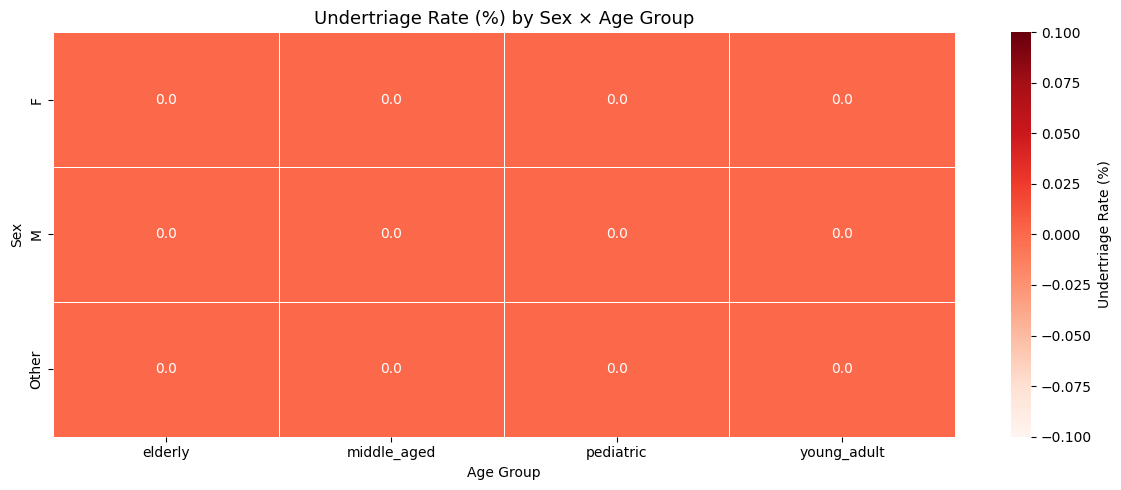

Undertriage heatmap saved.

Undertriage rates (%):
age_group  elderly  middle_aged  pediatric  young_adult
sex                                                    
F              0.0          0.0        0.0          0.0
M              0.0          0.0        0.0          0.0
Other          0.0          0.0        0.0          0.0


In [14]:
pivot = bias_df.groupby(['sex', 'age_group'])['undertriage'].mean() * 100
pivot = pivot.unstack()

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='Reds',
    ax=ax, cbar_kws={'label': 'Undertriage Rate (%)'},
    linewidths=0.5
)
ax.set_title('Undertriage Rate (%) by Sex × Age Group', fontsize=13)
ax.set_xlabel('Age Group')
ax.set_ylabel('Sex')
plt.tight_layout()
plt.savefig(WORKING_DIR + 'bias_undertriage_heatmap.png', dpi=150)
plt.show()

print('Undertriage heatmap saved.')
print('\nUndertriage rates (%):')
print(pivot.round(2))

### Step 7d — Confusion Matrices Per Subgroup

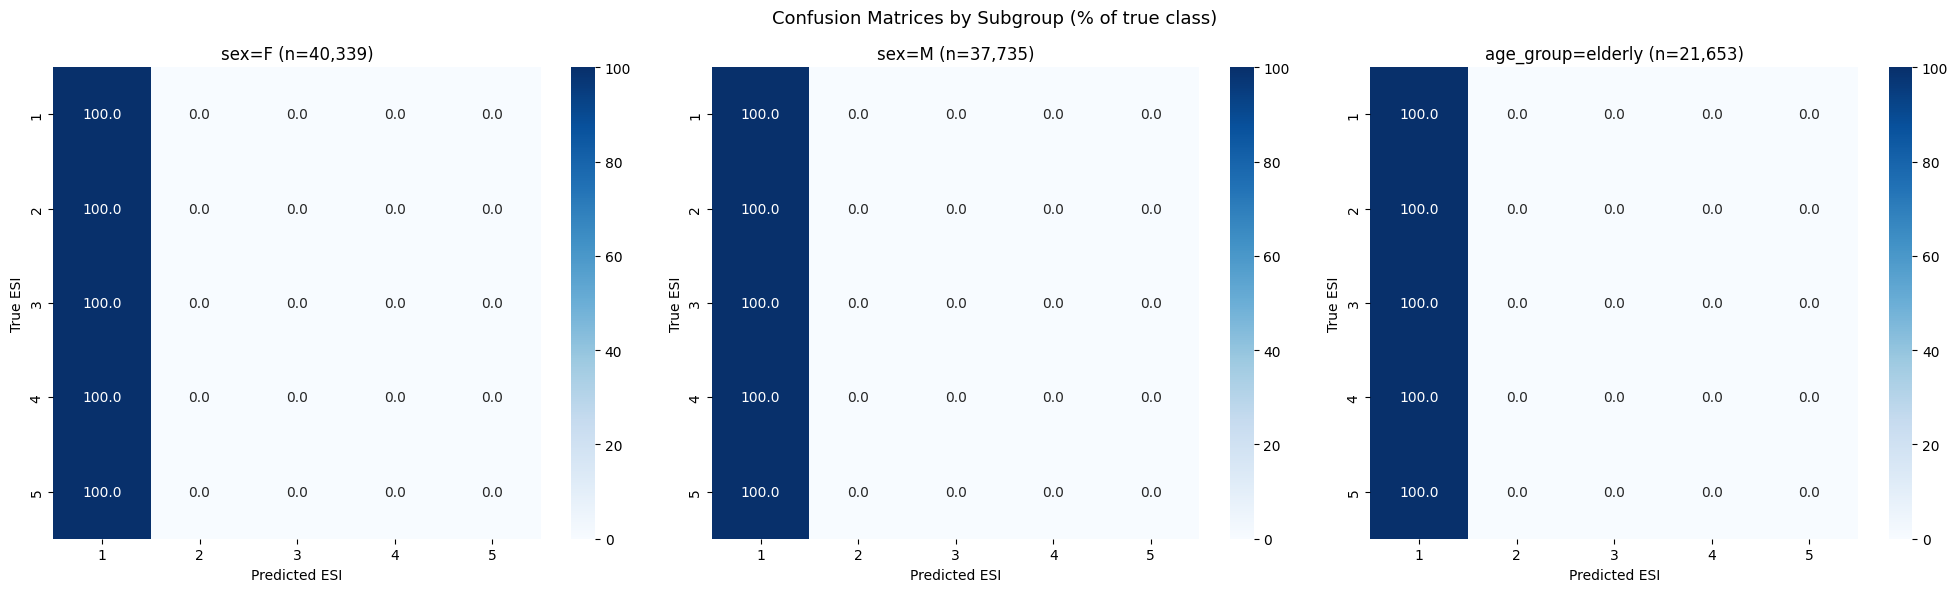

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

subgroups = [
    ('sex', 'F', axes[0]),
    ('sex', 'M', axes[1]),
    ('age_group', 'elderly', axes[2]),
]

for col, val, ax in subgroups:
    subset = bias_df[bias_df[col] == val]
    if len(subset) == 0:
        ax.set_title(f'{col}={val} (no data)')
        continue
    cm = confusion_matrix(
        subset['true_esi'], subset['pred_esi'],
        labels=[1,2,3,4,5], normalize='true'
    ) * 100

    sns.heatmap(
        cm, annot=True, fmt='.1f', cmap='Blues',
        ax=ax, xticklabels=[1,2,3,4,5],
        yticklabels=[1,2,3,4,5]
    )
    ax.set_title(f'{col}={val} (n={len(subset):,})')
    ax.set_xlabel('Predicted ESI')
    ax.set_ylabel('True ESI')

plt.suptitle('Confusion Matrices by Subgroup (% of true class)', fontsize=13)
plt.tight_layout()
plt.savefig(WORKING_DIR + 'bias_confusion_matrices.png', dpi=150)
plt.show()

### Step 7e — Arrival Mode Analysis


=== BIAS ANALYSIS BY ARRIVAL MODE ===

        arrival_mode      n  undertriage_%  overtriage_%  weighted_f1
0          ambulance  22404            0.0         95.94       0.0032
1  brought_by_family   5583            0.0         95.74       0.0035
2         helicopter   2405            0.0         95.30       0.0042
3             police   3162            0.0         96.08       0.0030
4           transfer   7987            0.0         96.07       0.0030
5            walk-in  38459            0.0         96.04       0.0030


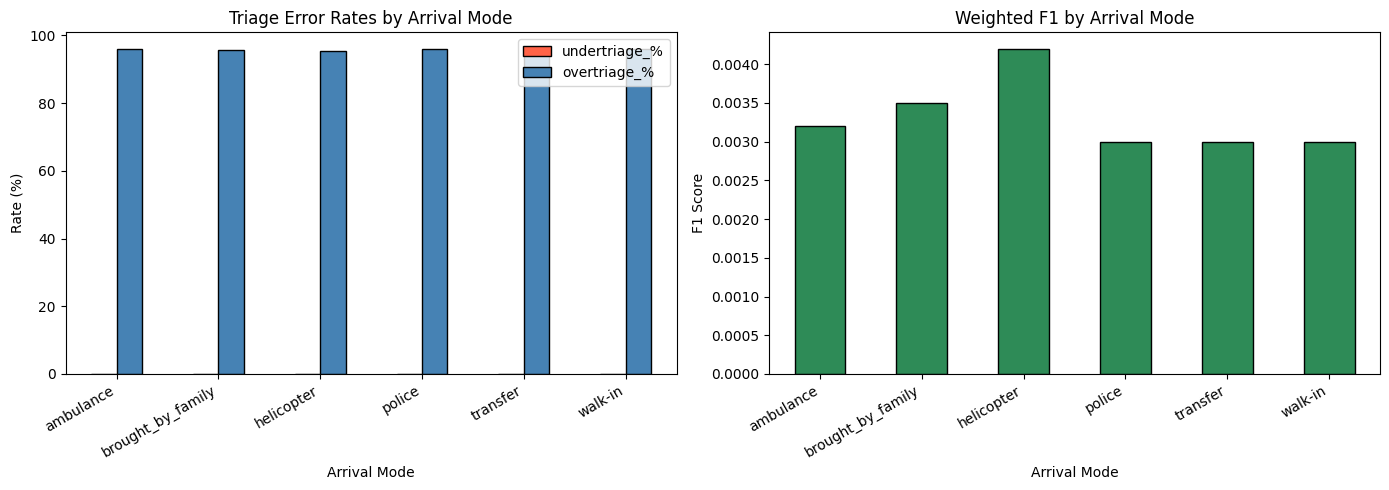


Bias analysis results saved.


In [16]:
print('\n=== BIAS ANALYSIS BY ARRIVAL MODE ===\n')

arrival_results = []
for mode in sorted(bias_df['arrival_mode'].unique()):
    subset = bias_df[bias_df['arrival_mode'] == mode]
    f1  = f1_score(subset['true_esi'], subset['pred_esi'],
                   average='weighted', labels=[1,2,3,4,5])
    ut  = subset['undertriage'].mean() * 100
    ot  = subset['overtriage'].mean() * 100
    arrival_results.append({
        'arrival_mode': mode, 'n': len(subset),
        'undertriage_%': round(ut, 2),
        'overtriage_%': round(ot, 2),
        'weighted_f1': round(f1, 4)
    })

arrival_results_df = pd.DataFrame(arrival_results)
print(arrival_results_df.sort_values('undertriage_%', ascending=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

arrival_results_df.set_index('arrival_mode')[['undertriage_%','overtriage_%']].plot(
    kind='bar', ax=axes[0], color=['tomato','steelblue'], edgecolor='black'
)
axes[0].set_title('Triage Error Rates by Arrival Mode')
axes[0].set_xlabel('Arrival Mode')
axes[0].set_ylabel('Rate (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

arrival_results_df.set_index('arrival_mode')['weighted_f1'].plot(
    kind='bar', ax=axes[1], color='seagreen', edgecolor='black'
)
axes[1].set_title('Weighted F1 by Arrival Mode')
axes[1].set_xlabel('Arrival Mode')
axes[1].set_ylabel('F1 Score')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig(WORKING_DIR + 'bias_arrival_mode.png', dpi=150)
plt.show()

import json
bias_summary = {
    'overall': {
        'accuracy': round(bias_df['correct'].mean()*100, 2),
        'undertriage_rate': round(bias_df['undertriage'].mean()*100, 2),
        'overtriage_rate':  round(bias_df['overtriage'].mean()*100, 2)
    },
    'by_sex':          sex_results,
    'by_age_group':    age_results,
    'by_arrival_mode': arrival_results
}

with open(WORKING_DIR + 'bias_analysis_results.json', 'w') as f:
    json.dump(bias_summary, f, indent=2)
print('\nBias analysis results saved.')

## Step 8 — SHAP Analysis

> Global feature importance + per-class + waterfall plots for ESI 1, 3, 5.

In [17]:
import shap

shap_model = lgbm_models[-1]  # last fold model

print('Computing SHAP values (this takes a few minutes)...')
explainer = shap.TreeExplainer(shap_model)

sample_idx = np.random.choice(len(X_train_full), 5000, replace=False)
X_sample = X_train_full.iloc[sample_idx]

shap_values = explainer.shap_values(X_sample)
print(f'SHAP values computed. Shape per class: {shap_values[0].shape}')

Computing SHAP values (this takes a few minutes)...
SHAP values computed. Shape per class: (448, 5)


### Step 8a — Global Feature Importance (All Classes)

Top 20 features by mean |SHAP|:
                     feature  mean_abs_shap
24                pain_score       1.062349
29               news2_score       0.520306
23                 gcs_total       0.499849
22                      spo2       0.156571
21             temperature_c       0.148530
70                    bert_1       0.131646
10      mental_status_triage       0.117839
17    mean_arterial_pressure       0.113677
275                tfidf_142       0.104302
11   num_prior_ed_visits_12m       0.103563
20          respiratory_rate       0.095447
111                  bert_42       0.091503
72                    bert_3       0.090140
116                  bert_47       0.069618
104                  bert_35       0.066918
114                  bert_45       0.061913
98                   bert_29       0.060338
96                   bert_27       0.059608
105                  bert_36       0.056425
69                    bert_0       0.048400


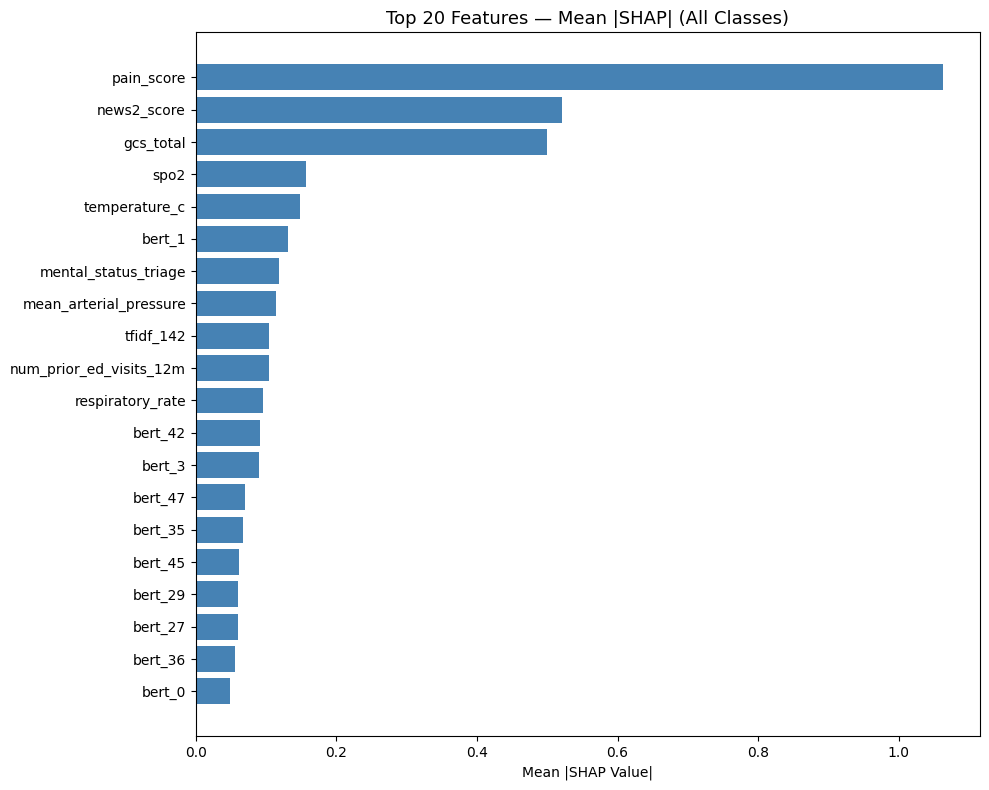

In [19]:
# Handle both old (list of 2D) and new (3D array) SHAP output formats
import numpy as np
import pandas as pd

if isinstance(shap_values, list):
    # Old format: list of [n_samples, n_features] arrays, one per class
    mean_shap = np.mean([np.abs(shap_values[c]) for c in range(5)], axis=0)
else:
    # New format: single array of shape [n_samples, n_features, n_classes]
    mean_shap = np.mean(np.abs(shap_values), axis=2)

global_importance = pd.DataFrame({
    'feature': X_train_full.columns,
    'mean_abs_shap': mean_shap.mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('Top 20 features by mean |SHAP|:')
print(global_importance.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 8))
top20 = global_importance.head(20)
ax.barh(top20['feature'][::-1], top20['mean_abs_shap'][::-1], color='steelblue')
ax.set_title('Top 20 Features — Mean |SHAP| (All Classes)', fontsize=13)
ax.set_xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.savefig(WORKING_DIR + 'shap_global_top20.png', dpi=150)
plt.show()

### Step 8b — SHAP for ESI 1 (Most Critical Class)

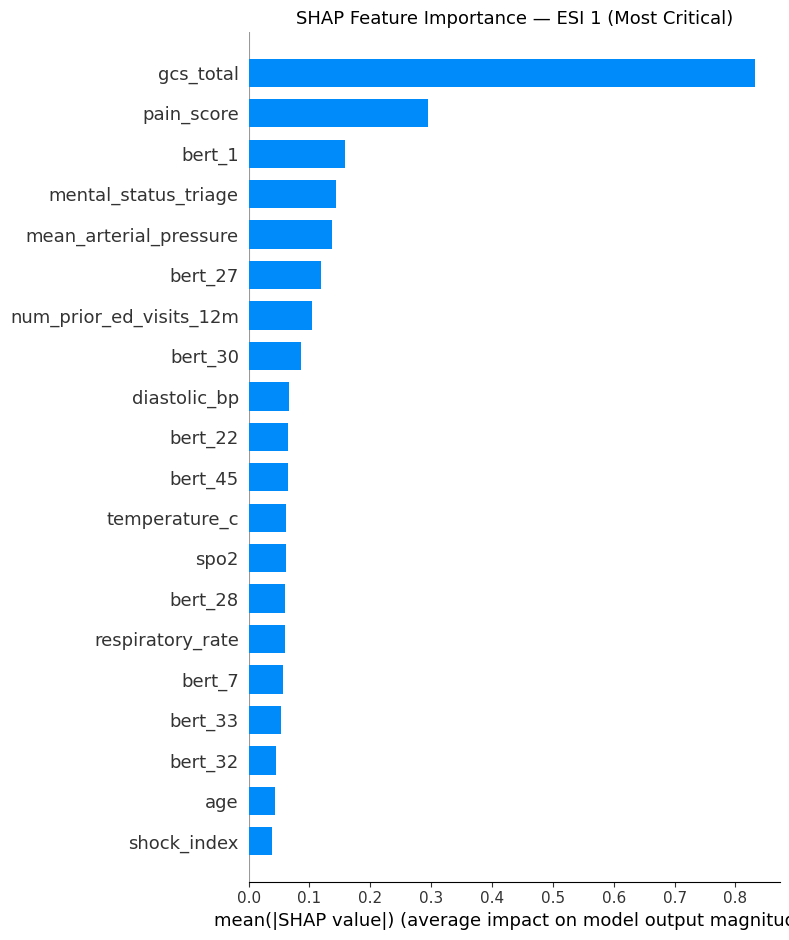

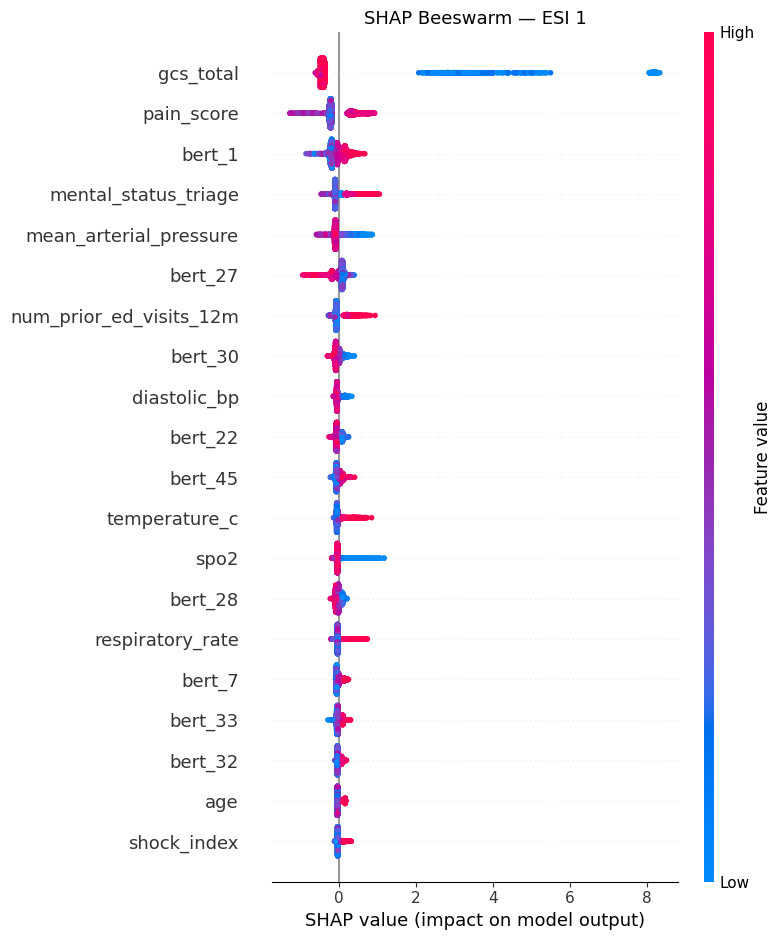

In [21]:
def get_class_shap(shap_values, class_idx):
    if isinstance(shap_values, list):
        return shap_values[class_idx]
    else:
        return shap_values[:, :, class_idx]

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(
    get_class_shap(shap_values, 0),
    X_sample,
    max_display=20,
    show=False,
    plot_type='bar'
)
plt.title('SHAP Feature Importance — ESI 1 (Most Critical)', fontsize=13)
plt.tight_layout()
plt.savefig(WORKING_DIR + 'shap_esi1_bar.png', dpi=150, bbox_inches='tight')
plt.show()

fig = plt.figure(figsize=(12, 8))
shap.summary_plot(
    get_class_shap(shap_values, 0),
    X_sample,
    max_display=20,
    show=False
)
plt.title('SHAP Beeswarm — ESI 1', fontsize=13)
plt.tight_layout()
plt.savefig(WORKING_DIR + 'shap_esi1_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 8c — Waterfall Plots (Local Explanations)


Waterfall plot for ESI 1 patient...


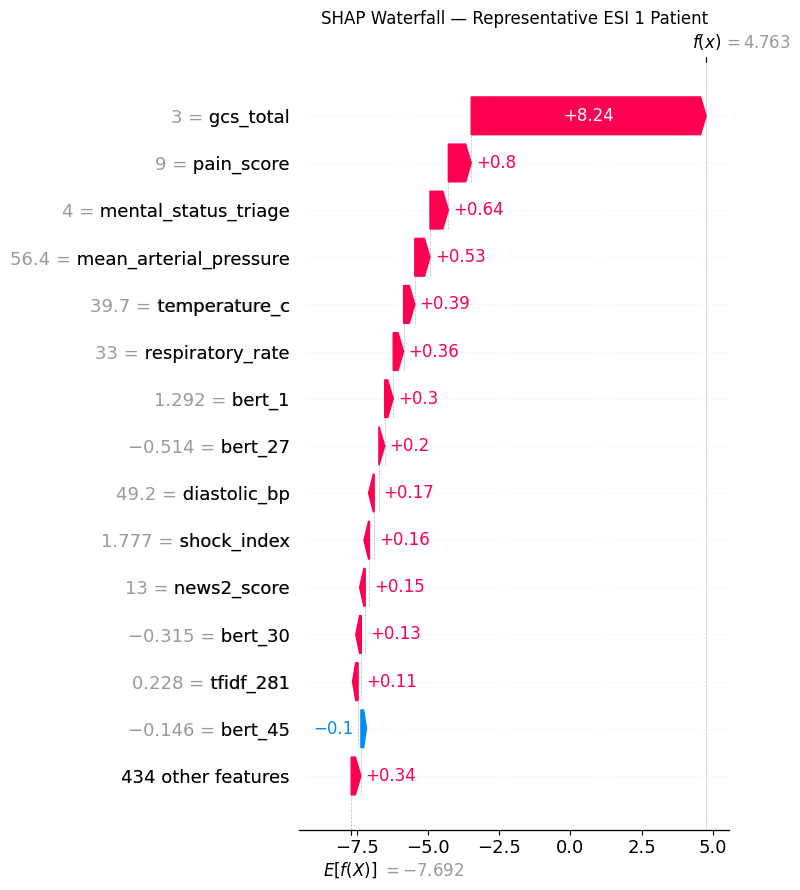


Waterfall plot for ESI 3 patient...


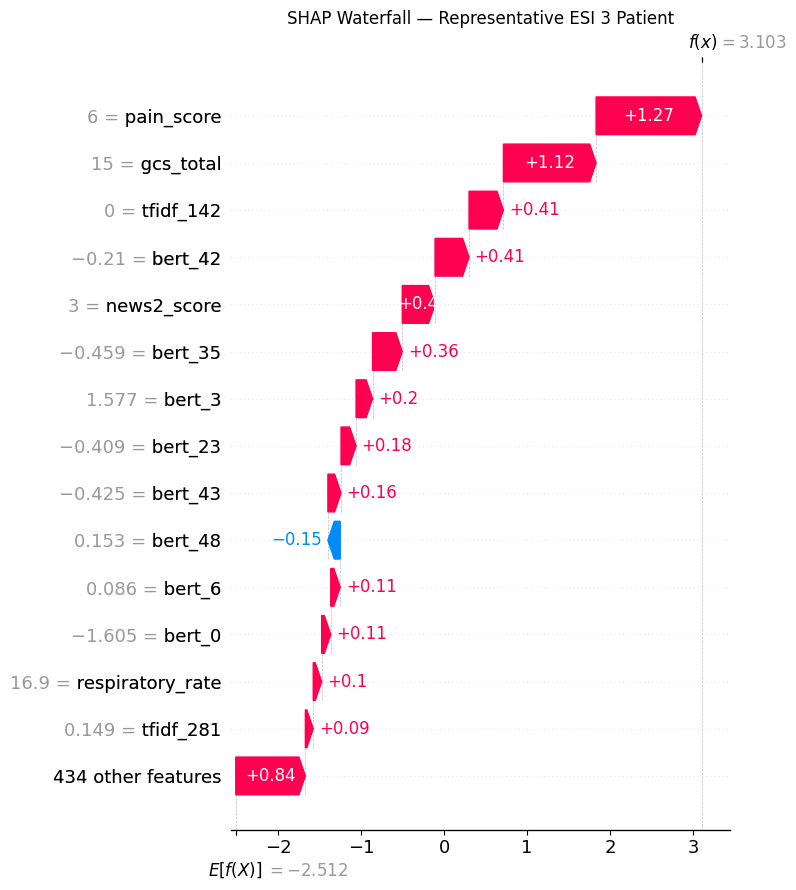


Waterfall plot for ESI 5 patient...


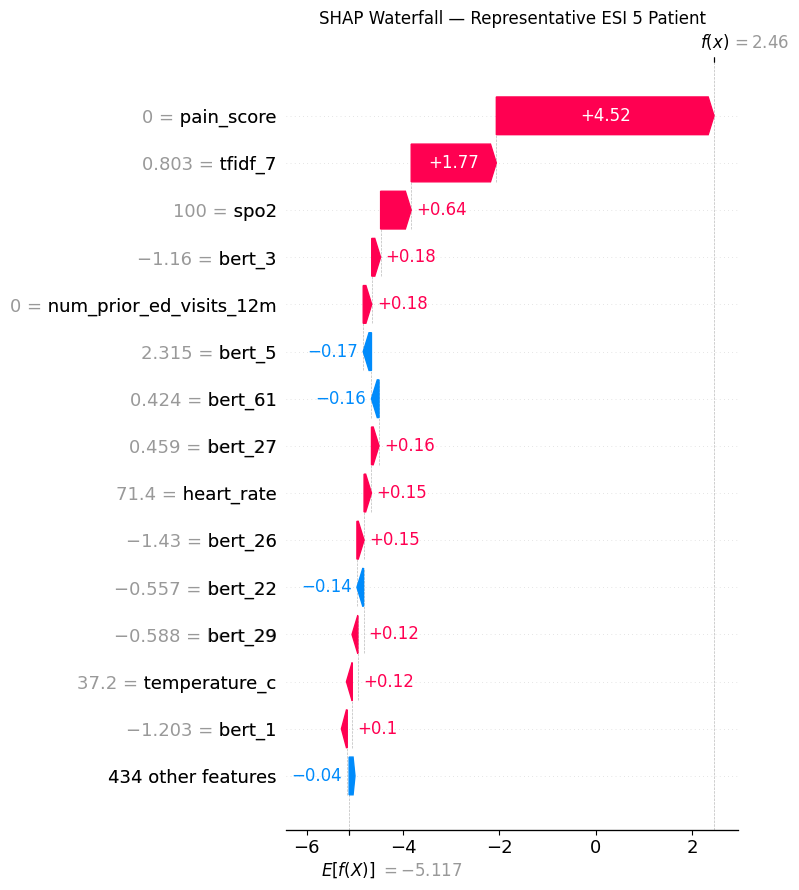

In [22]:
sample_labels = y[sample_idx]

esi1_idx = np.where(sample_labels == 0)[0][0]
esi3_idx = np.where(sample_labels == 2)[0][0]
esi5_idx = np.where(sample_labels == 4)[0][0]

for esi_label, idx, class_idx in [
    ('ESI 1', esi1_idx, 0),
    ('ESI 3', esi3_idx, 2),
    ('ESI 5', esi5_idx, 4)
]:
    print(f'\nWaterfall plot for {esi_label} patient...')
    shap_exp = shap.Explanation(
        values=get_class_shap(shap_values, class_idx)[idx],
        base_values=explainer.expected_value[class_idx],
        data=X_sample.iloc[idx].values,
        feature_names=X_train_full.columns.tolist()
    )
    fig = plt.figure(figsize=(12, 6))
    shap.waterfall_plot(shap_exp, max_display=15, show=False)
    plt.title(f'SHAP Waterfall — Representative {esi_label} Patient')
    plt.tight_layout()
    plt.savefig(WORKING_DIR + f'shap_waterfall_{esi_label.replace(" ","")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## Step 9 — Generate Final Submission

In [23]:
test_raw = pd.read_csv(os.path.join(triagegeist_path, 'test.csv'))

final_test_labels = np.argmax(final_test_preds, axis=1) + 1

submission = pd.DataFrame({
    'patient_id':    test_raw['patient_id'],
    'triage_acuity': final_test_labels
})

print('Submission shape:', submission.shape)
print('\nPredicted ESI distribution:')
print(submission['triage_acuity'].value_counts().sort_index())
print('\nExpected (from training):')
print(pd.Series(y+1).value_counts().sort_index())

assert submission.isnull().sum().sum() == 0, 'NaN in submission!'
assert submission['triage_acuity'].between(1,5).all(), 'ESI out of range!'

submission.to_csv(WORKING_DIR + 'submission_final.csv', index=False)
print('\nsubmission_final.csv saved.')
print(submission.head())

Submission shape: (20000, 2)

Predicted ESI distribution:
triage_acuity
1    20000
Name: count, dtype: int64

Expected (from training):
1     3222
2    13439
3    28921
4    23020
5    11398
Name: count, dtype: int64

submission_final.csv saved.
     patient_id  triage_acuity
0  TG-FZUFCRZS3              1
1  TG-SSCOXTYI1              1
2  TG-JY74ZR35D              1
3  TG-JDKD5G62X              1
4  TG-J1BSAAXR0              1


## Step 10 — Save Summary & Verify All Outputs

In [24]:
import json

phase3_summary = {
    'optuna_best_f1':     round(study.best_value, 4),
    'lgbm_tuned_f1':      round(lgbm_f1, 4),
    'lgbm_tuned_qwk':     round(lgbm_kappa, 4),
    'xgb_f1':             round(xgb_f1, 4),
    'xgb_qwk':            round(xgb_kappa, 4),
    'mlp_f1':             round(mlp_f1, 4),
    'mlp_qwk':            round(mlp_kappa, 4),
    'ensemble_f1':        round(final_f1, 4),
    'ensemble_qwk':       round(final_kappa, 4),
    'ensemble_method':    method_used,
    'phase2_f1':          0.9989,
    'improvement':        round(final_f1 - 0.9989, 4),
    'bias_overall_undertriage': bias_summary['overall']['undertriage_rate'],
}

with open(WORKING_DIR + 'phase3_summary.json', 'w') as f:
    json.dump(phase3_summary, f, indent=2)

print('Phase 3 summary:')
print(json.dumps(phase3_summary, indent=2))

print('\nAll Phase 3 files — output check:')
phase3_files = [
    'oof_lgbm_tuned.npy', 'test_lgbm_tuned.npy',
    'oof_xgb.npy',        'test_xgb.npy',
    'oof_mlp.npy',        'test_mlp.npy',
    'final_test_preds.npy', 'final_oof_preds.npy',
    'bias_analysis_results.json',
    'bias_undertriage_heatmap.png',
    'bias_confusion_matrices.png',
    'bias_arrival_mode.png',
    'shap_global_top20.png',
    'shap_esi1_bar.png',
    'shap_esi1_beeswarm.png',
    'shap_waterfall_ESI1.png',
    'shap_waterfall_ESI3.png',
    'shap_waterfall_ESI5.png',
    'submission_final.csv',
    'phase3_summary.json'
]
for fname in phase3_files:
    exists = '✅' if os.path.exists(WORKING_DIR + fname) else '❌'
    print(f'  {exists} {fname}')

Phase 3 summary:
{
  "optuna_best_f1": 0.9971,
  "lgbm_tuned_f1": 0.9975,
  "lgbm_tuned_qwk": 0.9987,
  "xgb_f1": 0.9985,
  "xgb_qwk": 0.9993,
  "mlp_f1": 0.0031,
  "mlp_qwk": 0.0,
  "ensemble_f1": 0.0031,
  "ensemble_qwk": 0.0,
  "ensemble_method": "soft_blend",
  "phase2_f1": 0.9989,
  "improvement": -0.9958,
  "bias_overall_undertriage": 0.0
}

All Phase 3 files — output check:
  ✅ oof_lgbm_tuned.npy
  ✅ test_lgbm_tuned.npy
  ✅ oof_xgb.npy
  ✅ test_xgb.npy
  ✅ oof_mlp.npy
  ✅ test_mlp.npy
  ✅ final_test_preds.npy
  ✅ final_oof_preds.npy
  ✅ bias_analysis_results.json
  ✅ bias_undertriage_heatmap.png
  ✅ bias_confusion_matrices.png
  ✅ bias_arrival_mode.png
  ✅ shap_global_top20.png
  ✅ shap_esi1_bar.png
  ✅ shap_esi1_beeswarm.png
  ✅ shap_waterfall_ESI1.png
  ✅ shap_waterfall_ESI3.png
  ✅ shap_waterfall_ESI5.png
  ✅ submission_final.csv
  ✅ phase3_summary.json


## Phase 3 Checklist

| Step | Task | Status |
|---|---|---|
| 0 | Load Phase 2 files + recompute class weights | ☐ |
| 1 | Optuna HPO — 100 trials, 3-fold CV | ☐ |
| 2 | Tuned LightGBM — 5-fold CV with best params | ☐ |
| 3 | XGBoost — 5-fold CV (CPU) | ☐ |
| 4 | PyTorch MLP — 5-fold CV | ☐ |
| 5 | Ensemble blending — grid search + rank avg | ☐ |
| 6 | Bias analysis — sex, age group, arrival mode | ☐ |
| 7 | Undertriage heatmap (sex × age group) | ☐ |
| 8 | Confusion matrices per subgroup | ☐ |
| 9 | SHAP global top 20 features | ☐ |
| 10 | SHAP waterfall plots for ESI 1, 3, 5 | ☐ |
| 11 | Generate submission_final.csv | ☐ |
| 12 | Save all outputs and verify | ☐ |

## Key Notes for Writeup

```
Optuna best params   : [paste from output]
Tuned LightGBM F1    : ___
XGBoost F1           : ___
MLP F1               : ___
Final ensemble F1    : ___
Final ensemble QWK   : ___
Ensemble method      : soft_blend / rank_avg
Best blend weights   : LGBM=___ XGB=___ MLP=___

Bias findings:
  Overall undertriage rate : ___%
  Highest undertriage group: ___
  Notable disparity         : [describe or 'none found']

SHAP top 3 features: [from output]
```